# Import Libs :

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Load Data :

In [31]:
def load_data(path):
    try:
        df = pd.read_csv(path)
        print(f'Data is loaded with : {len(df)} Rows')
        return df
    except Exception as e:
        print(f'You have a problem: {e}')
        return None

path = "../../data/processed/jobs.csv"
df = load_data(path)
df.head()

Data is loaded with : 672 Rows


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


# Data Info :

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    str    
 2   Salary Estimate    672 non-null    str    
 3   Job Description    672 non-null    str    
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    str    
 6   Location           672 non-null    str    
 7   Headquarters       672 non-null    str    
 8   Size               672 non-null    str    
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    str    
 11  Industry           672 non-null    str    
 12  Sector             672 non-null    str    
 13  Revenue            672 non-null    str    
 14  Competitors        672 non-null    str    
dtypes: float64(1), int64(2), str(12)
memory usage: 78.9 KB


# Data DEscribe :

### Num :

In [33]:
df.describe(include='number')

,index,Rating,Founded
count,672.000000,672.000000,672.000000
mean,335.500000,3.518601,1635.529762
std,194.133974,1.410329,756.746640
min,0.000000,-1.000000,-1.000000
25%,167.750000,3.300000,1917.750000
50%,335.500000,3.800000,1995.000000
75%,503.250000,4.300000,2009.000000
max,671.000000,5.000000,2019.000000


### Cat:

In [34]:
df.describe(include='object')

/tmp/ipykernel_624888/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Job Title,Salary Estimate,Job Description,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,Competitors
count,672,672,672,672,672,672,672,672,672,672,672,672
unique,172,30,489,432,207,229,9,13,58,23,14,108
top,Data Scientist,$75K-$131K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,Maxar Technologies\n3.5,"San Francisco, CA","New York, NY",51 to 200 employees,Company - Private,-1,Information Technology,Unknown / Non-Applicable,-1
freq,337,32,12,12,69,33,135,397,71,188,213,501


# Quality Check :

### Check -1 count:

In [35]:

def check_invalid_values(df, columns):
    for col in columns:
        count = df[col].isin([-1, "-1"]).sum()
        col_type = df[col].dtype
        print(f"{col}: {count} ==> {col_type}")
        print("="*35)

check_invalid_values(df, df.columns)

index: 0 ==> int64
Job Title: 0 ==> str
Salary Estimate: 0 ==> str
Job Description: 0 ==> str
Rating: 50 ==> float64
Company Name: 0 ==> str
Location: 0 ==> str
Headquarters: 31 ==> str
Size: 27 ==> str
Founded: 118 ==> int64
Type of ownership: 27 ==> str
Industry: 71 ==> str
Sector: 71 ==> str
Revenue: 27 ==> str
Competitors: 501 ==> str


| Column                | Missing | Type    | Recommended Action                                                      |
| --------------------- | ------- | ------- | ----------------------------------------------------------------------- |
| **Rating**            | 50      | float64 | `-1` → `NaN`, then impute with median or flag                           |
| **Headquarters**      | 31      | str     | `"-1"` → `'Unknown'` or keep as category                                |
| **Size**              | 27      | str     | `"-1"` → `'Unknown'` or mode imputation                                 |
| **Founded**           | 118     | int64   | `-1` → `NaN`, impute with median or create "Company Age" feature        |
| **Type of ownership** | 27      | str     | `"-1"` → `'Unknown'`                                                    |
| **Industry**          | 71      | str     | `"-1"` → `'Unknown'`                                                    |
| **Sector**            | 71      | str     | `"-1"` → `'Unknown'`                                                    |
| **Revenue**           | 27      | str     | `"-1"` → `'Unknown'` or ordinal encoding                                |
| **Competitors**       | 501     | str     | `"-1"` → `0` (count=0 competitors) or separate category                 |


### check Null :

In [36]:
def check_null(df):
    sum_null = df.isnull().sum()
    sum_sum_null = df.isnull().sum().sum()
    print(f"Total of null in all data :  {sum_sum_null}")
    print("="*35)
    print("="*35)
    print("sum of nul foreach column :")
    print(sum_null)

check_null(df)


Total of null in all data :  0
sum of nul foreach column :
index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64


### Check duplicated :

In [37]:
def check_dyplicated(df):
    sum_duplicated = df.duplicated().sum()
    if sum_duplicated == 0:
        print('You Dont Have Any Duplicated')
    else:
        print(f"Some Duplicated Detected : {sum_duplicated}")
check_dyplicated(df)

You Dont Have Any Duplicated


### Fix -1 Values :

In [38]:
numeric_cols = ['Rating', 'Founded']

for col in numeric_cols:
    df[col] = df[col].replace(-1, pd.NA)

string_cols = [
    'Headquarters',
    'Size',
    'Type of ownership',
    'Industry',
    'Sector',
    'Revenue',
    'Competitors'
]

for col in string_cols:
    df[col] = df[col].replace('-1', 'Unknown')

print("Missing values after cleaning:")
print(df[numeric_cols].isna().sum())

Missing values after cleaning:
Rating      50
Founded    118
dtype: int64


### Extract Salary :

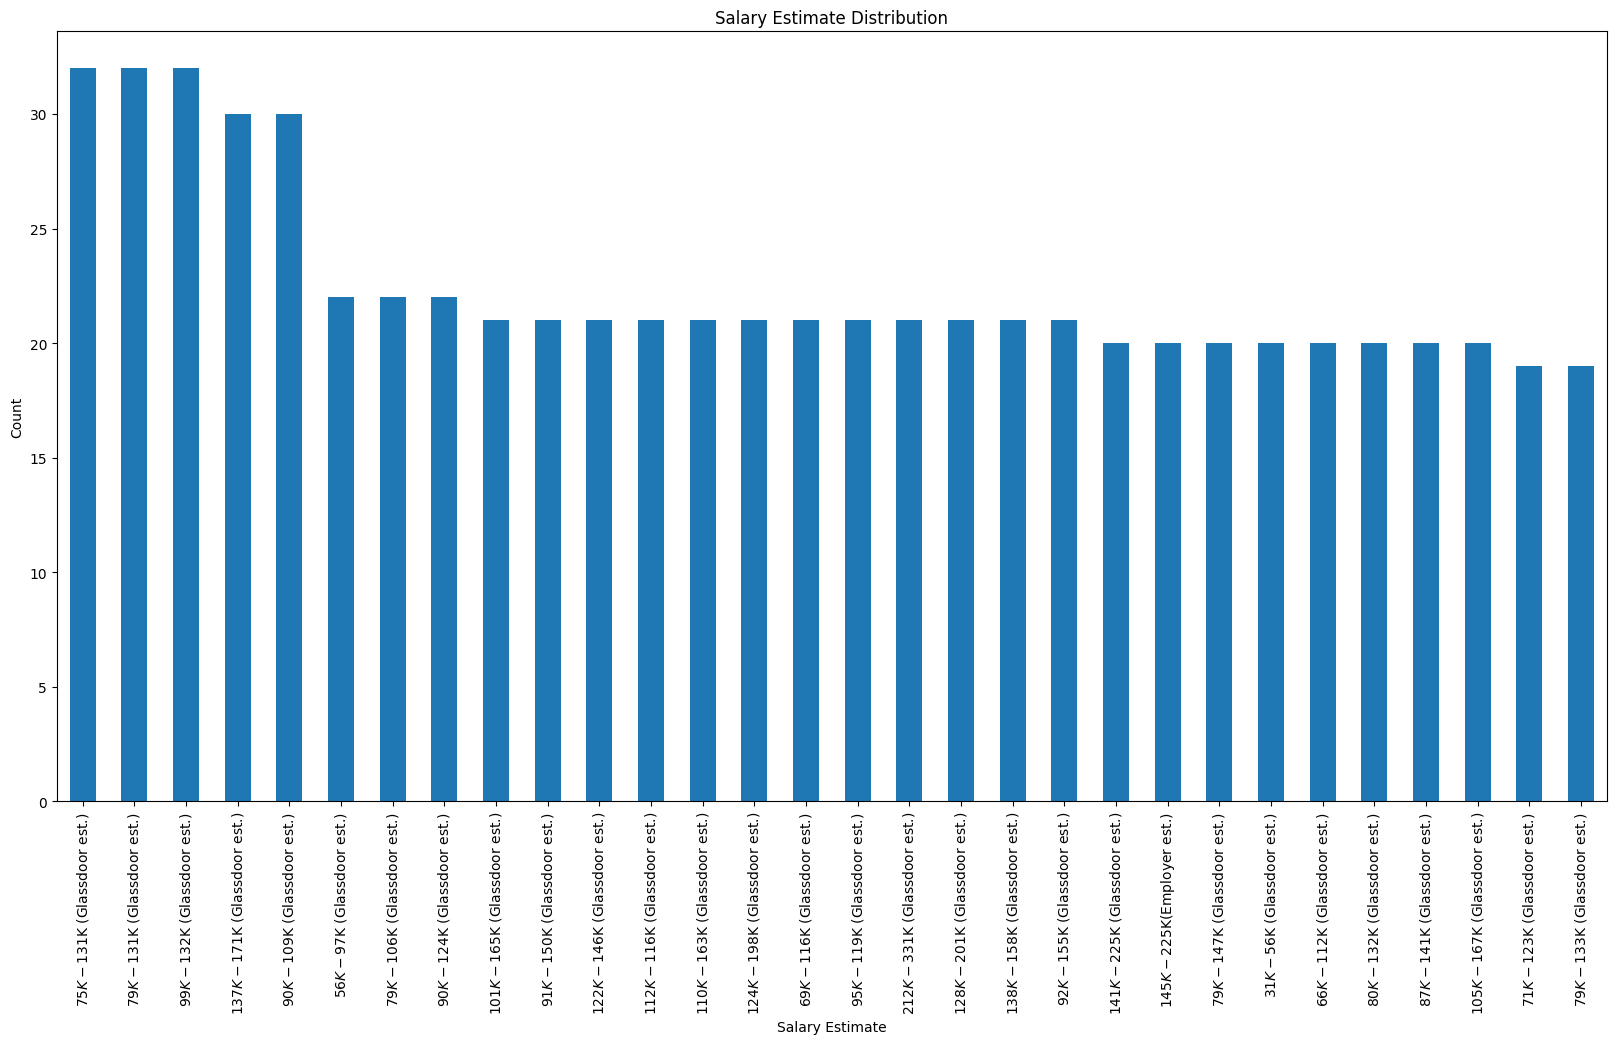

In [57]:
salary_estimate = df['Salary Estimate'].value_counts()

plt.figure(figsize=(20, 10))
salary_estimate.plot(kind='bar')
plt.title('Salary Estimate Distribution')
plt.xlabel('Salary Estimate')
plt.ylabel('Count')
plt.show()

In [ ]:
def clean_salary(salary):

    if pd.isna(salary) or salary == "-1":
        return pd.NA

    salary = salary.split("(")[0]

    salary = salary.replace("$", "").replace("K", "000")

    numbers = re.findall(r"\d+", salary)

    if len(numbers) >= 2:
        low = int(numbers[0])
        high = int(numbers[1])
        return (low + high) / 2

    return pd.NA

df["salary_clean"] = df["Salary Estimate"].apply(clean_salary)
df.head(100)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,salary_clean
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",154000.0
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),Unknown,154000.0
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),Unknown,154000.0
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",154000.0
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",154000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,Staff Data Scientist - Analytics,$99K-$132K (Glassdoor est.),Intuit is seeking a Staff Data Scientist to co...,4.4,Intuit - Data\n4.4,"San Diego, CA","Mountain View, CA",5001 to 10000 employees,1983,Company - Public,Computer Hardware & Software,Information Technology,$2 to $5 billion (USD),"Square, PayPal, H&R Block",115500.0
96,96,Data Analytics Engineer,$99K-$132K (Glassdoor est.),Our Data Analytics Engineer will engineer eleg...,3.5,QOMPLX\n3.5,"Reston, VA","Reston, VA",51 to 200 employees,2015,Company - Private,Enterprise Software & Network Solutions,Information Technology,$10 to $25 million (USD),Unknown,115500.0
97,97,"Data Scientist, Kinship - NYC/Portland",$99K-$132K (Glassdoor est.),Back to search results\nPrevious job\n\nNext j...,3.9,Mars\n3.9,"New York, NY","Mc Lean, VA",10000+ employees,1911,Company - Private,Food & Beverage Manufacturing,Manufacturing,$10+ billion (USD),Unknown,115500.0
98,98,Senior Data Scientist,$99K-$132K (Glassdoor est.),"About Us\n\nAt GutCheck, we pioneered agile ma...",3.8,GutCheck\n3.8,"Denver, CO","Denver, CO",51 to 200 employees,2009,Company - Private,Advertising & Marketing,Business Services,$10 to $25 million (USD),"Nielsen, Zappi, SurveyMonkey",115500.0


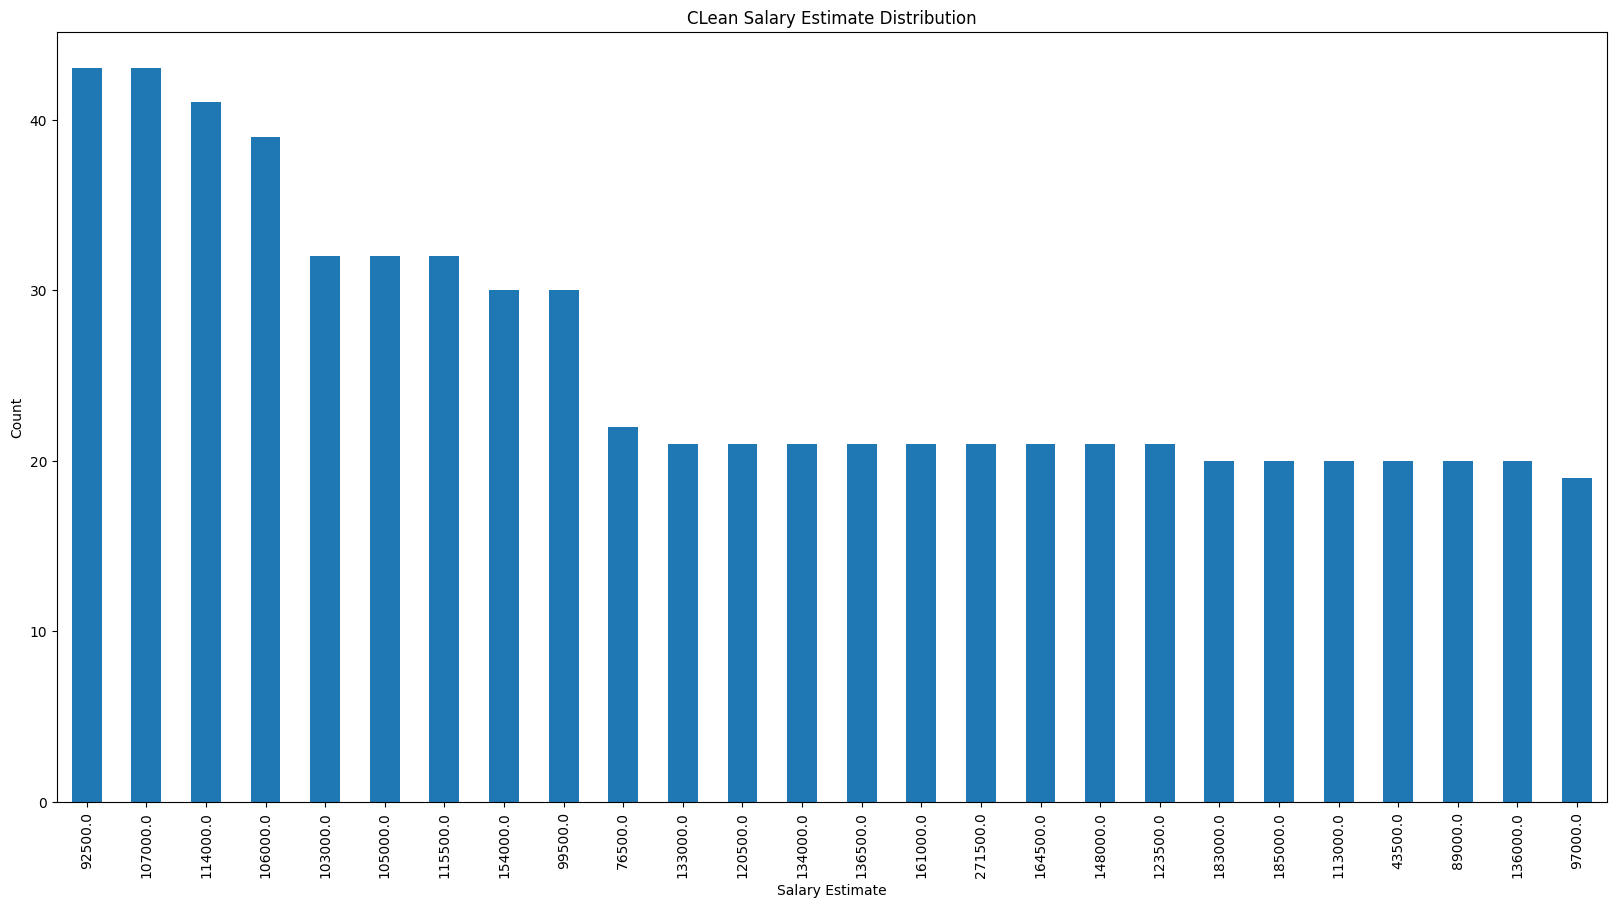

In [58]:
salary_estimate = df['salary_clean'].value_counts()

plt.figure(figsize=(20, 10))
salary_estimate.plot(kind='bar')
plt.title('CLean Salary Estimate Distribution')
plt.xlabel('Salary Estimate')
plt.ylabel('Count')
plt.show()

### Clean job Titel :

In [ ]:

jobtitel_count = df['Job Title'].unique()

<StringArray>
[                                                 'Sr Data Scientist',
                                                     'Data Scientist',
                           'Data Scientist / Machine Learning Expert',
                                   'Staff Data Scientist - Analytics',
                          'Data Scientist - Statistics, Early Career',
                                                       'Data Modeler',
                                         'Experienced Data Scientist',
                                          'Data Scientist - Contract',
                                                    'Data Analyst II',
                                              'Medical Lab Scientist',
 ...
 'Information Systems Engineering Specialist (Engineering Scientist)',
                 'Scientist/Research Associate-Metabolic Engineering',
            'Vice President, Biometrics and Clinical Data Management',
   'Enterprise Data Analyst (Enterprise Portfolio Manageme